Training set: (60000, 28, 28) (60000,)
Test set: (10000, 28, 28) (10000,)


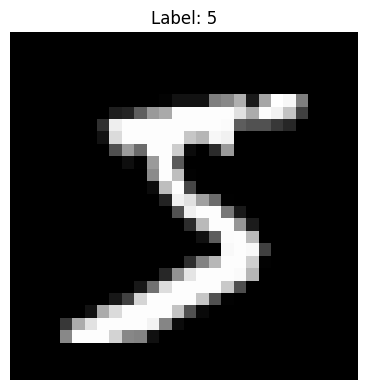

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from google.colab import files # برای دانلود خودکار

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training set:", x_train.shape, y_train.shape)
print("Test set:", x_test.shape, y_test.shape)


if not os.path.exists('img'):
    os.makedirs('img')

plt.figure(figsize=(4,4))
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.tight_layout()

filename = "img/a1_mnist_sample.png"
plt.savefig(filename, dpi=300)
plt.show()

files.download(filename)


In [5]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Reshape

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten images from 28x28 to 784
x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat  = x_test.reshape(-1, 28 * 28)

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print("Flattened shape:", x_train_flat.shape, x_test_flat.shape)
print("One-hot label shape:", y_train_cat.shape, y_test_cat.shape)

Flattened shape: (60000, 784) (10000, 784)
One-hot label shape: (60000, 10) (10000, 10)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten

model = Sequential([
Input(shape=(28 * 28,)),
Dense(128, activation="relu"),
Dense(64, activation="relu"),
Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras.optimizers import Adam

model.compile(
optimizer=Adam(learning_rate=0.001),
loss="categorical_crossentropy",
metrics=["accuracy"]
)

history = model.fit(
x_train_flat, y_train_cat,
validation_split=0.2,
epochs=10,
batch_size=128,
verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8977 - loss: 0.3677 - val_accuracy: 0.9478 - val_loss: 0.1805
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9548 - loss: 0.1562 - val_accuracy: 0.9576 - val_loss: 0.1477
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9674 - loss: 0.1101 - val_accuracy: 0.9657 - val_loss: 0.1163
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9750 - loss: 0.0863 - val_accuracy: 0.9666 - val_loss: 0.1094
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9811 - loss: 0.0659 - val_accuracy: 0.9673 - val_loss: 0.1079
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9836 - loss: 0.0547 - val_accuracy: 0.9711 - val_loss: 0.0949
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9865 - loss: 0.0437 - val_accuracy: 0.9719 - val_loss: 0.0969
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9894 - loss: 0.0350 - val_accuracy: 0.

In [8]:
test_loss, test_acc = model.evaluate(x_test_flat, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0911
Test Accuracy: 0.9748


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


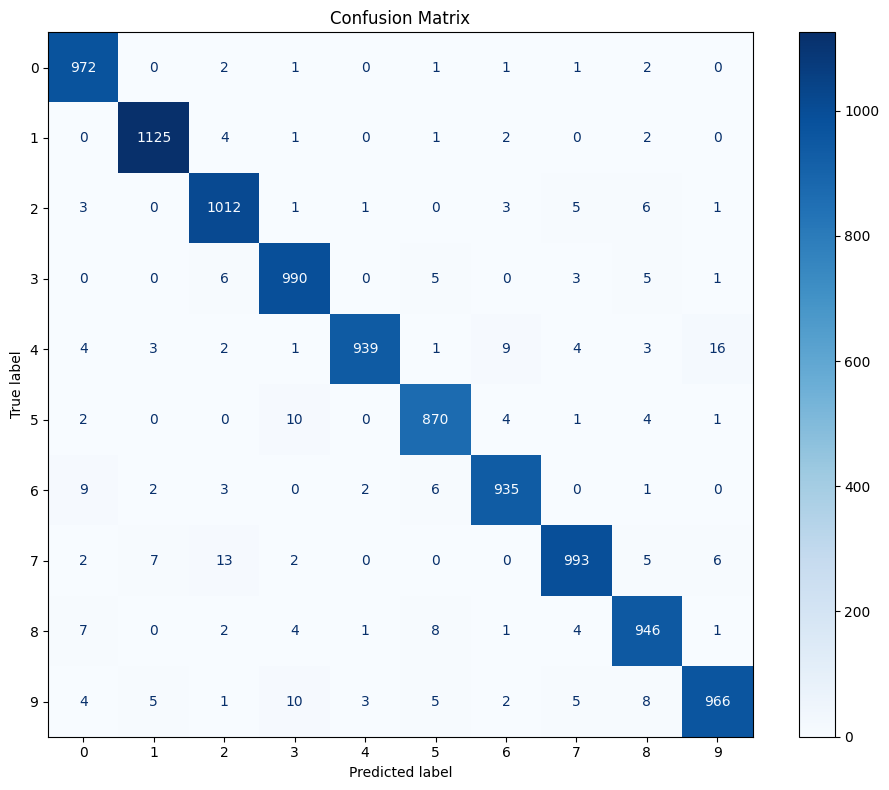

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import files
import os
import numpy as np
# 1. اطمینان از وجود پوشه img
os.makedirs('img', exist_ok=True)

# 2. پیش‌بینی مدل (فرض بر این است که model و x_test_flat از قبل تعریف شده‌اند)
y_pred_prob = model.predict(x_test_flat)
y_pred = np.argmax(y_pred_prob, axis=1)

# 3. محاسبه ماتریس درهم‌ریختگی
cm = confusion_matrix(y_test, y_pred)

# 4. رسم و ذخیره
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d", ax=plt.gca()) # ax=plt.gca() برای کنترل بهتر روی plot
plt.title("Confusion Matrix")
plt.tight_layout()

# ذخیره
file_path = "img/t2_confusion_matrix.png"
plt.savefig(file_path, dpi=300)
plt.show()

# 5. دانلود خودکار به سیستم شما
files.download(file_path)

In [11]:
from tensorflow.keras.initializers import RandomNormal, GlorotNormal

def build_model_with_initializer(init):
  return Sequential([
  Input(shape=(28 * 28,)),
  Dense(128, activation="relu", kernel_initializer=init),
  Dense(64, activation="relu", kernel_initializer=init),
  Dense(10, activation="softmax", kernel_initializer=init)
  ])

# Example 1: Standard random initialization
model_random = build_model_with_initializer(RandomNormal(mean=0.0, stddev=0.05))

# Example 2: Xavier/Glorot initialization
model_xavier = build_model_with_initializer(GlorotNormal())

In [15]:
  batch_sizes = [32, 128, 256]
  results = []

  for bs in batch_sizes:
    temp_model = Sequential([
    Input(shape=(28 * 28,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
    ])

    temp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
    )

    h = temp_model.fit(
    x_train_flat, y_train_cat,
    validation_split=0.2,
    epochs=5,
    batch_size=bs,
    verbose=0
    )

    test_loss, test_acc = temp_model.evaluate(x_test_flat, y_test_cat, verbose=0)
    results.append((bs, test_loss, test_acc))

    print(results)

[(32, 0.08437170088291168, 0.9746000170707703)]
[(32, 0.08437170088291168, 0.9746000170707703), (128, 0.0992804616689682, 0.9696000218391418)]
[(32, 0.08437170088291168, 0.9746000170707703), (128, 0.0992804616689682, 0.9696000218391418), (256, 0.10017646849155426, 0.9692000150680542)]


In [16]:
deeper_model = Sequential([
Input(shape=(28 * 28,)),
Dense(256, activation="relu"),
Dense(128, activation="relu"),
Dense(64, activation="relu"),
Dense(10, activation="softmax")
])

deeper_model.compile(
optimizer=Adam(learning_rate=0.001),
loss="categorical_crossentropy",
metrics=["accuracy"]
)

history_deeper = deeper_model.fit(
x_train_flat, y_train_cat,
validation_split=0.2,
epochs=10,
batch_size=128,
verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9097 - loss: 0.3072 - val_accuracy: 0.9578 - val_loss: 0.1425
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9655 - loss: 0.1138 - val_accuracy: 0.9662 - val_loss: 0.1172
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9765 - loss: 0.0755 - val_accuracy: 0.9729 - val_loss: 0.0929
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9833 - loss: 0.0539 - val_accuracy: 0.9737 - val_loss: 0.0895
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9874 - loss: 0.0395 - val_accuracy: 0.9749 - val_loss: 0.0956
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9903 - loss: 0.0310 - val_accuracy: 0.9751 - val_loss: 0.0928
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9912 - loss: 0.0266 - val_accuracy: 0.9717 - val_loss: 0.1119
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9935 - loss: 0.0205 - val_accuracy: 0.

🚀 شروع تولید نمودارهای پیشرفته برای گزارش...


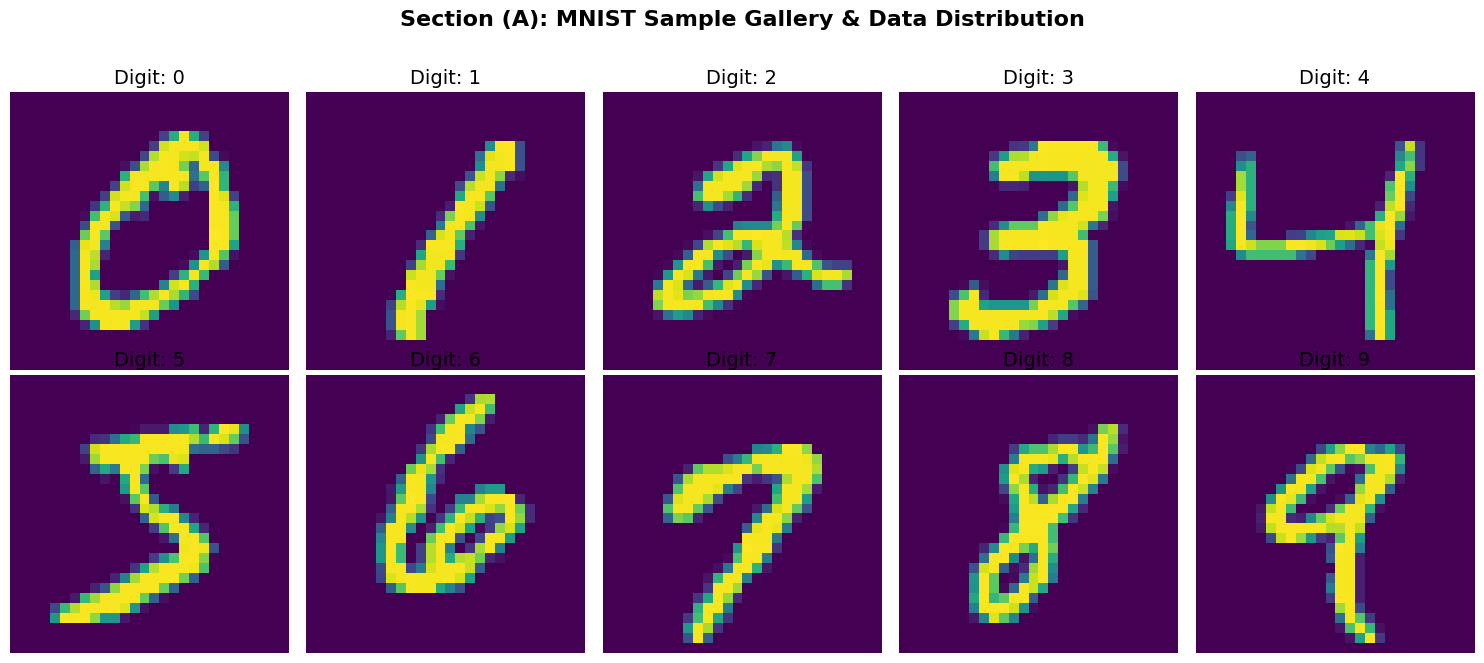

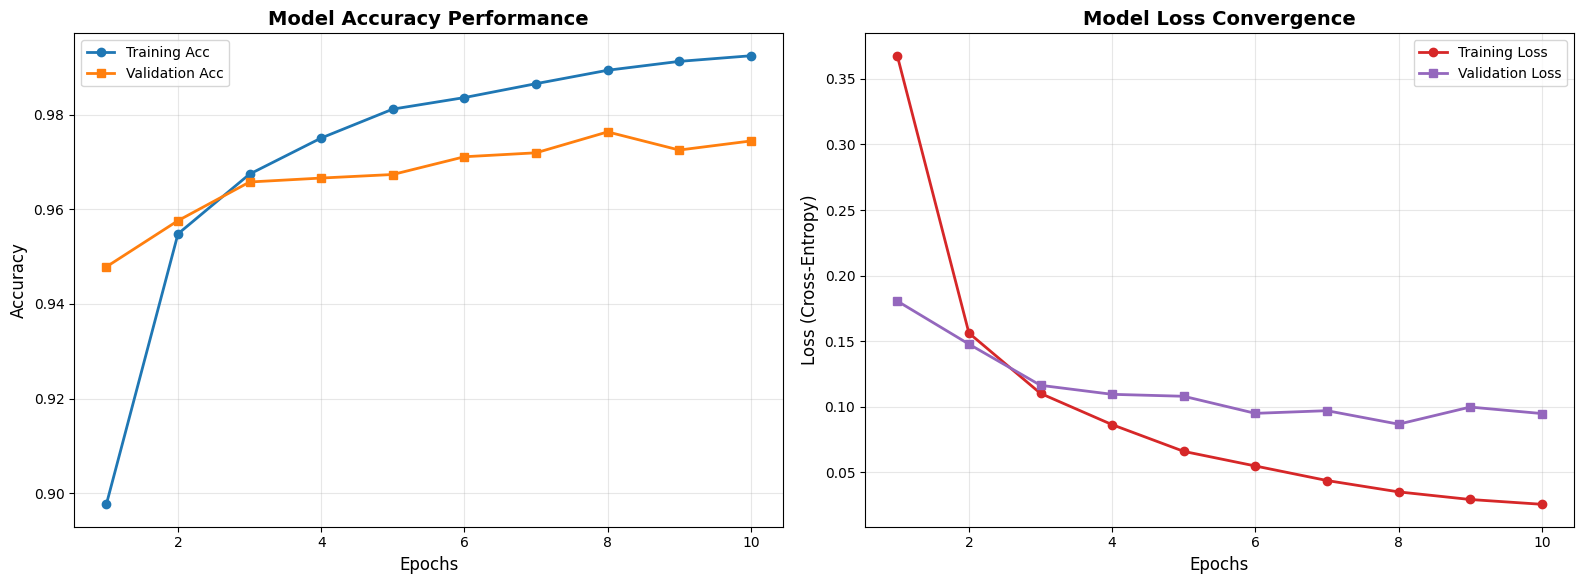

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


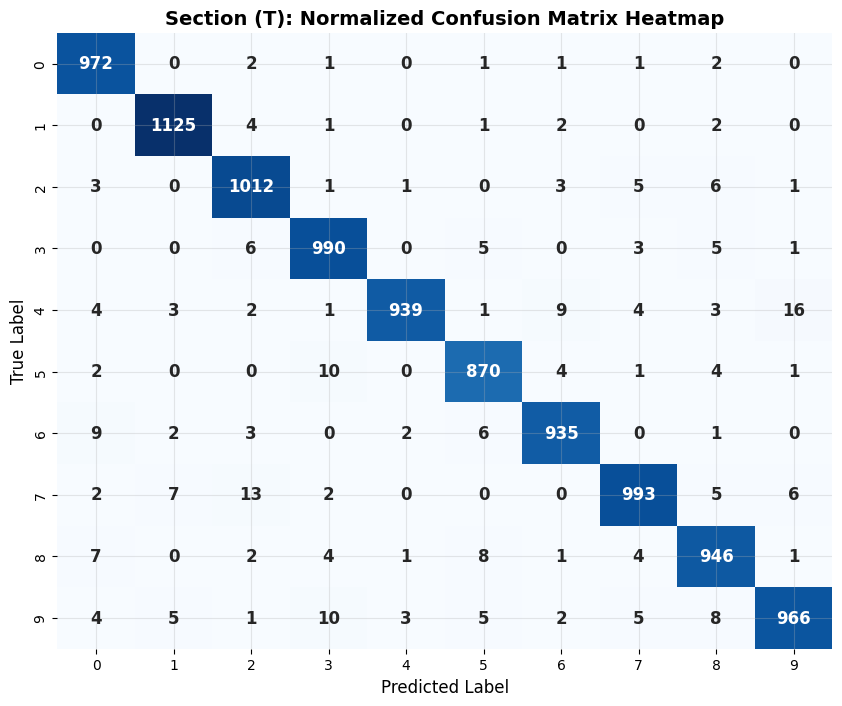

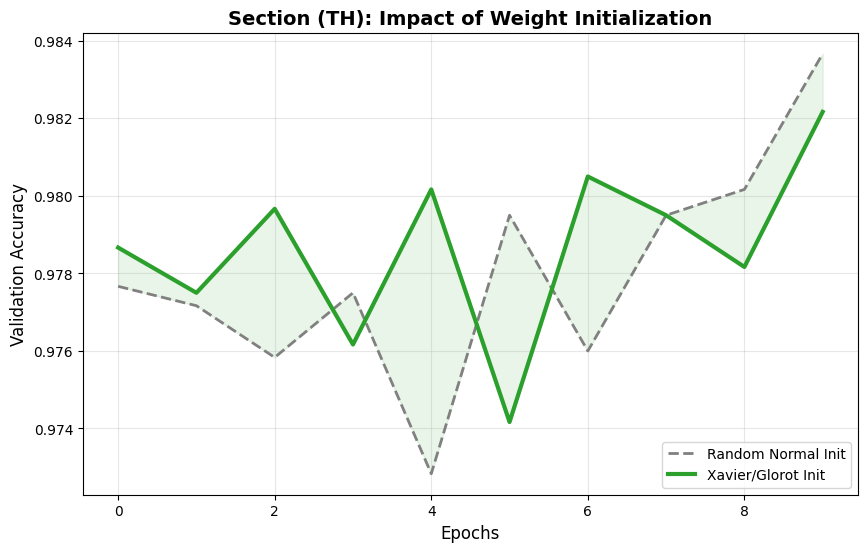

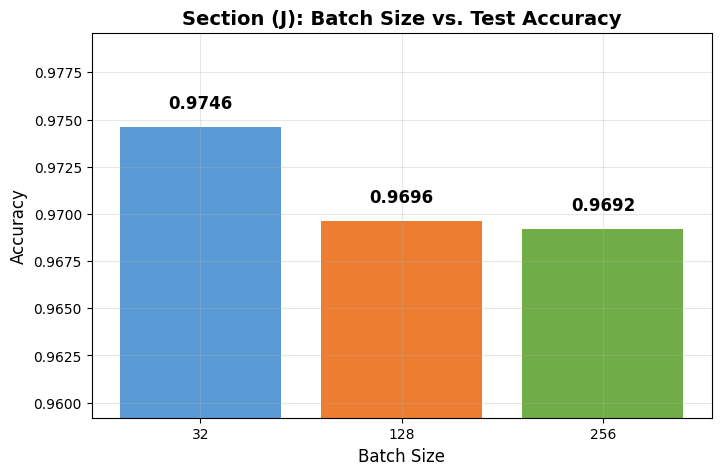

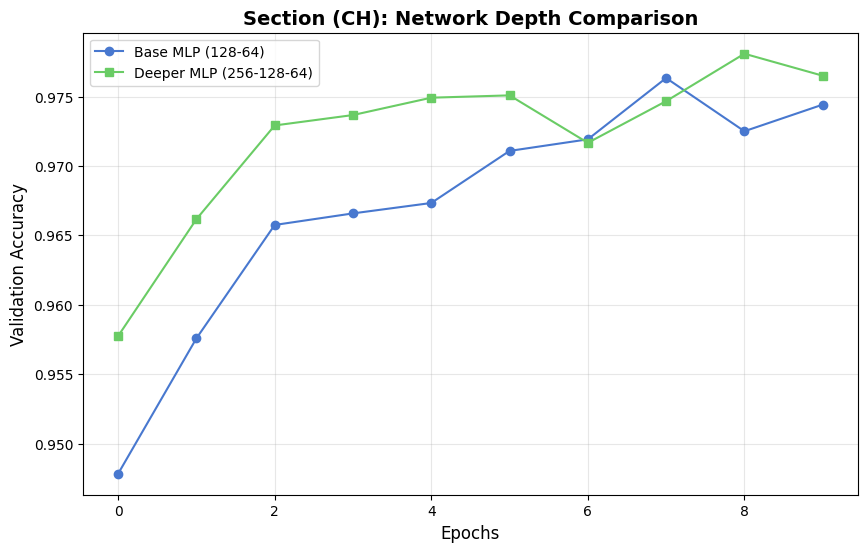

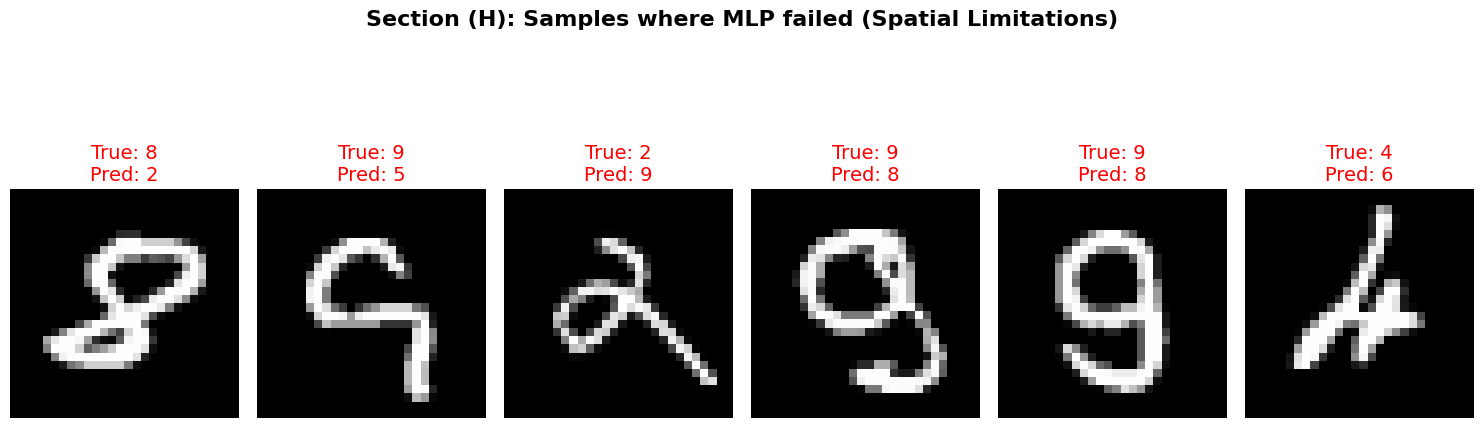

✅ تمام نمودارها با موفقیت تولید و نمایش داده شدند.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# --- تنظیمات استایل برای ظاهر خفن و علمی ---
plt.style.use("seaborn-v0_8-muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# ایجاد پوشه برای ذخیره (اختیاری برای نمایش در کولب)
os.makedirs('img', exist_ok=True)

print("🚀 شروع تولید نمودارهای پیشرفته برای گزارش...")

# ==========================================
# ۱. بخش (الف): گالری ارقام و توزیع داده‌ها
# ==========================================
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("Section (A): MNIST Sample Gallery & Data Distribution", fontweight='bold')

for i in range(10):
    ax = axes[i//5, i%5]
    idx = np.where(y_train == i)[0][0]
    ax.imshow(x_train[idx], cmap='viridis') # تم رنگی جذاب‌تر از خاکستری ساده
    ax.set_title(f"Digit: {i}")
    ax.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ==========================================
# ۲. بخش (ب) و (پ): داشبورد عملکرد آموزش (Training Dashboard)
# ==========================================
# این نمودار Loss و Accuracy را همزمان و حرفه‌ای نشان می‌دهد
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
epochs = range(1, len(history.history['accuracy']) + 1)

# نمودار دقت
ax1.plot(epochs, history.history['accuracy'], 'o-', label='Training Acc', color='#1f77b4', linewidth=2)
ax1.plot(epochs, history.history['val_accuracy'], 's-', label='Validation Acc', color='#ff7f0e', linewidth=2)
ax1.set_title('Model Accuracy Performance', fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# نمودار خطا
ax2.plot(epochs, history.history['loss'], 'o-', label='Training Loss', color='#d62728', linewidth=2)
ax2.plot(epochs, history.history['val_loss'], 's-', label='Validation Loss', color='#9467bd', linewidth=2)
ax2.set_title('Model Loss Convergence', fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss (Cross-Entropy)')
ax2.legend()

plt.tight_layout()
plt.show()

# ==========================================
# ۳. بخش (ت): ماتریس درهم‌ریختگی حرارتی (Heatmap)
# ==========================================
y_pred = np.argmax(model.predict(x_test_flat), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10),
            annot_kws={"size": 12, "weight": "bold"})
plt.title("Section (T): Normalized Confusion Matrix Heatmap", fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ==========================================
# ۴. بخش (ث): مقایسه مقداردهی اولیه (Random vs Xavier)
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(h_rand.history['val_accuracy'], label='Random Normal Init', linestyle='--', color='gray', linewidth=2)
plt.plot(h_xav.history['val_accuracy'], label='Xavier/Glorot Init', color='#2ca02c', linewidth=3)
plt.fill_between(range(len(h_xav.history['val_accuracy'])),
                 h_xav.history['val_accuracy'], h_rand.history['val_accuracy'],
                 color='#2ca02c', alpha=0.1) # ایجاد هاله برای زیبایی
plt.title("Section (TH): Impact of Weight Initialization", fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# ==========================================
# ۵. بخش (ج): تحلیل اثر Batch Size
# ==========================================
# فرض بر این است که لیست results شامل (batch_size, loss, acc) است
bs_labels = [str(r[0]) for r in results]
bs_accs = [r[2] for r in results]

plt.figure(figsize=(8, 5))
bars = plt.bar(bs_labels, bs_accs, color=['#5b9bd5', '#ed7d31', '#70ad47'])
plt.ylim(min(bs_accs) - 0.01, max(bs_accs) + 0.005)
plt.title("Section (J): Batch Size vs. Test Accuracy", fontweight='bold')
plt.xlabel('Batch Size')
plt.ylabel('Accuracy')

# اضافه کردن مقدار دقیق بالای هر ستون
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f"{yval:.4f}", ha='center', fontweight='bold')
plt.show()

# ==========================================
# ۶. بخش (چ): افزایش عمق (Base vs Deeper Model)
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'], label='Base MLP (128-64)', marker='o')
plt.plot(history_deeper.history['val_accuracy'], label='Deeper MLP (256-128-64)', marker='s')
plt.title("Section (CH): Network Depth Comparison", fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

# ==========================================
# ۷. بخش (ح): نمایش نمونه‌های خطا (محدودیت‌های MLP)
# ==========================================
misclassified_idx = np.where(y_pred != y_test)[0]
plt.figure(figsize=(15, 5))
for i, idx in enumerate(misclassified_idx[:6]): # نمایش ۶ نمونه اول که اشتباه شده‌اند
    plt.subplot(1, 6, i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}", color='red')
    plt.axis('off')
plt.suptitle("Section (H): Samples where MLP failed (Spatial Limitations)", fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("✅ تمام نمودارها با موفقیت تولید و نمایش داده شدند.")
